## 1.프로젝트 개요

#  캡스톤 디자인: 공사장 안전장비 실시간 감지 시스템 (EZ-safe)
- **팀원**: 최성용(회로/코딩), 구민서(3D 케이스), 권은지(앱 개발/BLE), 이명은(BLE 로직/테스트)
- **개발 기간**: 4월 ~ 6월 (총 16주차)

### 1) 배경 및 필요성
- 공사 현장에서 보호구 미착용으로 인한 추락, 충격 등 인명 사고가 빈번히 발생함.
- 기존의 CCTV 모니터링이나 수동 점검 방식은 실시간 확인이 어렵고 즉각적인 대응에 한계가 있음.

### 2) 프로젝트 목표
- **ESP32**와 다양한 센서(압력, 기울기)를 결합하여 안전모 및 안전조끼의 착용 상태를 실시간 감지.
- **BLE(Bluetooth Low Energy) 통신**의 RSSI(신호 세기) 기반 거리 인식을 통해 미착용 및 이탈 시 즉각적인 경고 시스템 구현.

##  2. 시스템 구조도 및 알고리즘
본 시스템은 **송신기(작업자 장비) -> 수신기(중계기) -> 스마트폰 앱(App Inventor)** 구조로 동작합니다.

1. **RSSI 측정**: 무선 신호 세기를 기반으로 작업자가 일정 거리 이상 이탈했는지 확인합니다.
   - RSSI $\ge$ -30 dBm: 강한 신호 (가까움)
   - RSSI $\le$ -60 dBm: 약한 신호 (멀어짐 / 미착용 의심)
2. **센서 데이터 수집**: 안전모 내부의 압력 센서와 기울기 센서 값을 측정하여 실제 착용 여부 및 낙상(이상 상태)을 감지합니다.
3. **경고 출력**: 조건 만족 시 현장 부저(Buzzer) 경고음 발생 및 스마트폰 앱으로 실시간 데이터 전송.

In [ ]:
### 코드

#include <BLEDevice.h>
#include <BLEUtils.h>
#include <BLEScan.h>
#include <BLEAdvertisedDevice.h>
#include <BluetoothSerial.h>  // 블루투스 시리얼용

BluetoothSerial SerialBT;

const String WORKER1_MAC = "ec:e3:34:bf:80:9e";
const String WORKER2_MAC = "ec:e3:34:c0:5b:f6";

BLEScan* pBLEScan;
const int SCAN_TIME = 2;

struct WorkerData {
  bool dataReceived = false;
  int rssi = 0;
  String advData = "";
  char buzzerState = 'N'; // B or N
};

WorkerData worker1, worker2;

unsigned long lastSendTime = 0;
const unsigned long SEND_INTERVAL = 1000;
bool sendWorker1Next = true;

class MyAdvertisedDeviceCallbacks : public BLEAdvertisedDeviceCallbacks {
  void onResult(BLEAdvertisedDevice advertisedDevice) override {
    String mac = advertisedDevice.getAddress().toString();
    mac.toLowerCase();

    if (mac == WORKER1_MAC || mac == WORKER2_MAC) {
      String adv = advertisedDevice.getManufacturerData().c_str();
      if (adv.length() == 0) {
        adv = advertisedDevice.toString().c_str();
      }

      int rssi = advertisedDevice.getRSSI();
      char buzzerChar = 'N';

      if (adv.length() > 0) {
        char lastChar = adv.charAt(adv.length() - 1);
        if (lastChar == 'B' || lastChar == 'N') {
          buzzerChar = lastChar;
        }
      }

      if (mac == WORKER1_MAC) {
        worker1.dataReceived = true;
        worker1.rssi = rssi;
        worker1.advData = adv;
        worker1.buzzerState = buzzerChar;
      } else {
        worker2.dataReceived = true;
        worker2.rssi = rssi;
        worker2.advData = adv;
        worker2.buzzerState = buzzerChar;
      }
    }
  }
};

void setup() {
  Serial.begin(115200);
  Serial.println("중계기 BLE + 블루투스 시리얼 시작");

  // 블루투스 시리얼 초기화
  SerialBT.begin("RelayDeviceBT");  // 스마트폰에서 이 이름으로 표시됨
  Serial.println("Bluetooth Serial 시작됨: RelayDeviceBT");

  // BLE 초기화
  BLEDevice::init("Relay-Device");
  pBLEScan = BLEDevice::getScan();
  pBLEScan->setAdvertisedDeviceCallbacks(new MyAdvertisedDeviceCallbacks());
  pBLEScan->setActiveScan(true);
  pBLEScan->setInterval(100);
  pBLEScan->setWindow(99);
}

void loop() {
  BLEScanResults* results = pBLEScan->start(SCAN_TIME, false);
  if (results->getCount() == 0) {
    worker1.dataReceived = false;
    worker2.dataReceived = false;
  }
  pBLEScan->clearResults();

  // 디버그용 시리얼 출력
  if (worker1.dataReceived) {
    Serial.printf("작업자1 수신됨 - RSSI: %d, 부저: %c\n", worker1.rssi, worker1.buzzerState);
    Serial.printf("  데이터: %s\n", worker1.advData.c_str());
  } else {
    Serial.println("작업자1 데이터 수신 안됨");
  }

  if (worker2.dataReceived) {
    Serial.printf("작업자2 수신됨 - RSSI: %d, 부저: %c\n", worker2.rssi, worker2.buzzerState);
    Serial.printf("  데이터: %s\n", worker2.advData.c_str());
  } else {
    Serial.println("작업자2 데이터 수신 안됨");
  }

  // 앱인벤터로 블루투스 전송 (한글 메시지)
  if (millis() - lastSendTime >= SEND_INTERVAL) {
    lastSendTime = millis();

    if (sendWorker1Next) {
      if (worker1.dataReceived) {
        String message = "작업자1: ";
        message += (worker1.buzzerState == 'B') ? "착용불량" : "정상착용";
        SerialBT.println(message);
        Serial.println(">> 앱인벤터 전송 - " + message);
      } else {
        SerialBT.println("작업자1: 데이터 없음");
        Serial.println(">> 앱인벤터 전송 - 작업자1 데이터 없음");
      }
    } else {
      if (worker2.dataReceived) {
        String message = "작업자2: ";
        message += (worker2.buzzerState == 'B') ? "착용불량" : "정상착용";
        SerialBT.println(message);
        Serial.println(">> 앱인벤터 전송 - " + message);
      } else {
        SerialBT.println("작업자2: 데이터 없음");
        Serial.println(">> 앱인벤터 전송 - 작업자2 데이터 없음");
      }
    }

    sendWorker1Next = !sendWorker1Next;
  }

  delay(100);
}


## 🔧 3. 세부 구현 내용

### 1) 하드웨어 구성 (HW BOM)
- **컨트롤러**: ESP32 개발 보드 (내장 BLE 모듈 활용)
- **센서류**: 압전 센서(FSR RA12P)를 통한 착용 압력 감지, 기울기 센서를 통한 낙상 감지
- **전원 및 출력**: 3.7V 리튬 배터리, TP4056 충전 모듈, MT3608 승압 컨버터, 3V 능동 부저
- **외관 케이스**: 현장 환경을 고려해 높은 강도, 내열성, 내습성, 유연성을 가진 **PETG 필라멘트**를 사용하여 3D 프린팅 설계 및 제작

### 2) 소프트웨어 및 앱 개발
- **ESP32 코딩**: 센서 입력값 판별 ➡️ 문자열 형태 변환 ➡️ BLE 통신 송출 로직 설계
- **앱 인벤터(App Inventor)**: BLE로 중계기 데이터를 받아 스플릿/파싱하여 각 작업자의 착용 상태를 UI에 실시간 시각화 구현

## 📸 4. 최종 완제품 및 하드웨어 패키징 (EZ-safe 외관)

실제 산업 현장에서 사용할 수 있도록 내구성과 실용성을 고려하여 하드웨어를 최종 패키징하였습니다.

[최종 완제품 사진]

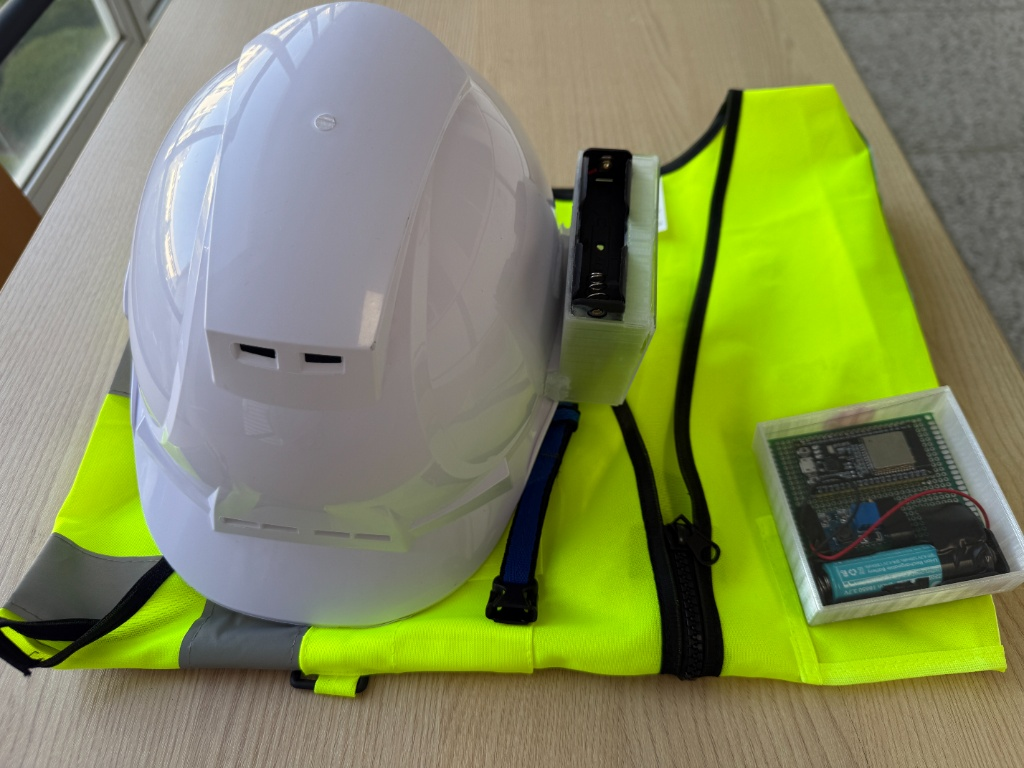



### 🛠️ 하드웨어 패키징의 주요 특징
1. **현장 맞춤형 3D 케이스 설계**: 
   - 공사 현장의 거친 환경을 고려하여 내열성, 내습성, 그리고 충격 유연성이 뛰어난 **PETG 필라멘트**를 채택하여 케이스를 직접 출력 및 가공했습니다.
   - 안전모의 곡률과 구조를 반영하여 작업자의 착용감에 방해가 되지 않도록 컴팩트하게 설계했습니다.
2. **안정적인 전원 및 출력부 통합**:
   - 내부에는 3.7V 리튬 배터리와 함께 전압 강하를 방지하는 **MT3608 승압 컨버터**를 내장하여 능동 부저가 항상 일정한 광량/음량으로 경고를 보낼 수 있도록 회로를 안정화했습니다.
   - 기판 후면은 **절연 처리**를 통해 현장 조립 중 발생할 수 있는 쇼트(Short) 오작동을 원천 차단했습니다.

## 5. 최종 완제품 및 하드웨어 패키징 (EZ-safe 외관)

실제 산업 현장에서 사용할 수 있도록 내구성과 실용성을 고려하여 하드웨어를 최종 패키징하였습니다.

![최종 완제품 사진](KakaoTalk_20260528_164647377.jpg)

### 🛠️ 하드웨어 패키징의 주요 특징
1. **현장 맞춤형 3D 케이스 설계**: 
   - 공사 현장의 거친 환경을 고려하여 내열성, 내습성, 그리고 충격 유연성이 뛰어난 **PETG 필라멘트**를 채택하여 케이스를 직접 출력 및 가공했습니다.
   - 안전모의 곡률과 구조를 반영하여 작업자의 착용감에 방해가 되지 않도록 컴팩트하게 설계했습니다.
2. **안정적인 전원 및 출력부 통합**:
   - 내부에는 3.7V 리튬 배터리와 함께 전압 강하를 방지하는 **MT3608 승압 컨버터**를 내장하여 능동 부저가 항상 일정한 광량/음량으로 경고를 보낼 수 있도록 회로를 안정화했습니다.
   - 기판 후면은 **절연 처리**를 통해 현장 조립 중 발생할 수 있는 쇼트(Short) 오작동을 원천 차단했습니다.

## 6. 결과 분석 및 기대효과

### 1) 테스트 결과
- 실전 시연을 통해 짧은 반응 속도와 안정적인 작동성 검증 완료.
- 수동 점검 방식 대비 자동화 시스템 구축으로 휴먼 에러 차단 가능.
- 아두이노 및 기성 센서 기반으로 제작되어 기존 고가 시스템 대비 **저전력/저비용**으로 즉시 도입 가능함.

### 2) 향후 발전 방향
- 현재 구축된 BLE 인프라에 추가로 **GPS 및 RFID** 모듈을 연동한다면 단순 착용 감지를 넘어 **정밀 위치 기반 관제 시스템**으로 확장 가능함.